In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Initial definition of functions using Bentkus et al. (2006)

In [2]:
def phi(x):
    return norm.pdf(x)

def G(x):
    return 1-norm.cdf(x)

def M(x):
    return phi(x)/G(x)


def v1(x):
    return M(x)
    
def v2(x):
    return 1/(M(x)-x)

def v3(x):
    return (2*M(x) - 2*x)/(x**2 + 1 - x*M(x))

def vartheta_v1(h):
    x = v1(h)
    return G(h) / G(x)

def vartheta_v2(h):
    x = v2(h)
    return (phi(h) - h*G(h)) / ((x-h)*G(x))

def vartheta_v3(h):
    x = v3(h)
    return ((1 + h**2)*G(h) - h*phi(h)) / ((x-h)**2*G(x))



def f1(x, delta, c = np.e):
    return x + (v1(x) - x)*G(v1(x))*(vartheta_v1(x)/delta)

def f2(x, delta, c = np.e**2/2):
    return x + (v2(x) - x)*(G(v2(x))*(vartheta_v2(x)/delta))**(1/2)

def f3(x, delta, c = 2*np.e**3/9):
    return x + (v3(x) - x)*(G(v3(x))*(vartheta_v3(x)/delta))**(1/3)

def A(x, delta):
    return (np.log(1/delta) + x**2 / 2)/x

def f_subg(delta):
    return np.sqrt(2 *np.log(1/delta))

def g(delta):
    return norm.ppf(1-delta)

Definition of functions using recursive formula

In [3]:
def phi(x): 
    return norm.pdf(x)

def G(x): 
    return 1 - norm.cdf(x)

def M(x): 
    return phi(x) / G(x)

# ---------------------------------------------------------
# Polynomial Helpers J_k(x) matching Appendix C
# ---------------------------------------------------------
def J0(x): return 1.0 + 0*x
def J1(x): return M(x) - x
def J2(x): return 1 + x**2 - x*M(x)
def J3(x): return (x**2 + 2)*M(x) - (x**3 + 3*x)
def J4(x): return (x**4 + 6*x**2 + 3) - (x**3 + 5*x)*M(x)
def J5(x): return (x**4 + 9*x**2 + 8)*M(x) - (x**5 + 10*x**3 + 15*x)
def J6(x): return (x**6 + 15*x**4 + 45*x**2 + 15) - (x**5 + 14*x**3 + 33*x)*M(x)

# ---------------------------------------------------------
# V_alpha(x) functions
# ---------------------------------------------------------
def v1(x): return M(x)
def v2(x): return 1 / J1(x)
def v3(x): return 2 * J1(x) / J2(x)
def v4(x): return 3 * J2(x) / J3(x)
def v5(x): return 4 * J3(x) / J4(x)
def v6(x): return 5 * J4(x) / J5(x)
def v7(x): return 6 * J5(x) / J6(x)

# ---------------------------------------------------------
# vartheta_alpha(h) functions
# ---------------------------------------------------------
def vartheta_v1(h):
    x = v1(h)
    return J0(h) * G(h) / G(x)  # J0(h) is just 1

def vartheta_v2(h):
    x = v2(h)
    return J1(h) * G(h) / ((x - h)**1 * G(x))

def vartheta_v3(h):
    x = v3(h)
    return J2(h) * G(h) / ((x - h)**2 * G(x))

def vartheta_v4(h):
    x = v4(h)
    return J3(h) * G(h) / ((x - h)**3 * G(x))

def vartheta_v5(h):
    x = v5(h)
    return J4(h) * G(h) / ((x - h)**4 * G(x))

def vartheta_v6(h):
    x = v6(h)
    return J5(h) * G(h) / ((x - h)**5 * G(x))

def vartheta_v7(h):
    x = v7(h)
    return J6(h) * G(h) / ((x - h)**6 * G(x))

# ---------------------------------------------------------
# Threshold bounding functions f_alpha(x, delta)
# ---------------------------------------------------------
def f0(x, delta):
    # np.where(condition, value_if_true, value_if_false)
    return np.where(G(x) <= delta, x, np.inf)

def f1(x, delta):
    return x + (v1(x) - x) * (G(v1(x)) * (vartheta_v1(x) / delta))**(1/1)

def f2(x, delta):
    return x + (v2(x) - x) * (G(v2(x)) * (vartheta_v2(x) / delta))**(1/2)

def f3(x, delta):
    return x + (v3(x) - x) * (G(v3(x)) * (vartheta_v3(x) / delta))**(1/3)

def f4(x, delta):
    return x + (v4(x) - x) * (G(v4(x)) * (vartheta_v4(x) / delta))**(1/4)

def f5(x, delta):
    return x + (v5(x) - x) * (G(v5(x)) * (vartheta_v5(x) / delta))**(1/5)

def f6(x, delta):
    return x + (v6(x) - x) * (G(v6(x)) * (vartheta_v6(x) / delta))**(1/6)

def f7(x, delta):
    return x + (v7(x) - x) * (G(v7(x)) * (vartheta_v7(x) / delta))**(1/7)

# ---------------------------------------------------------
# Baselines
# ---------------------------------------------------------
def A(x, delta):
    return (np.log(1/delta) + x**2 / 2) / x

def f_subg(delta):
    return np.sqrt(2 * np.log(1/delta))

def g(delta):
    return norm.ppf(1 - delta)

# Vanilla plot

/tmp/ipykernel_616934/3690063925.py:95: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2) / x


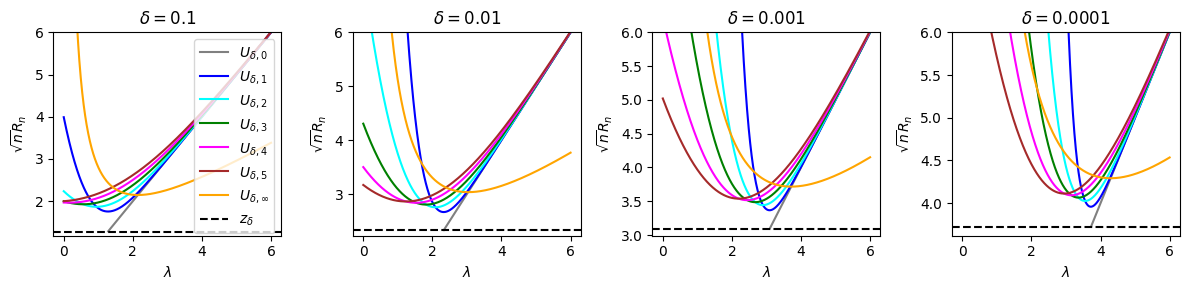

In [11]:
# deltas = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
# fig, axes = plt.subplots(3, 3, figsize=(10, 10))

deltas = [0.1, 0.01, 0.001, 0.0001]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):

    y = f0(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 0}}$", color='gray')
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='cyan')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    y = f4(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    y = f5(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 5}}$", color='brown')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, \infty}}$", color='orange')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc = 'upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot.png", dpi=300)
plt.show()

# Post-hoc inference

vline 2 no red line

/tmp/ipykernel_616934/3690063925.py:95: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2) / x


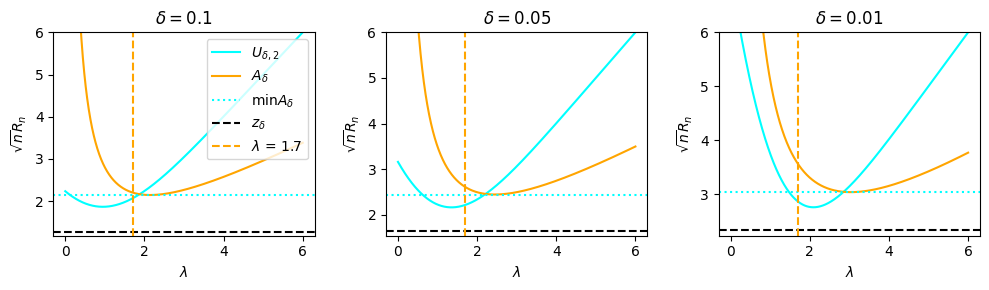

In [12]:
deltas = [0.1, 0.05, 0.01]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    # y = f1(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='cyan')
    
    # y = f3(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    # y = f4(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    # y = f5(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 5}}$", color='brown')
    
    y_A = A(x, delta)
    ax.plot(x, y_A, label=fr"$A_{{\delta}}$", color='orange')

    # --- NEW: Plot horizontal line at the minimum of A_delta on the grid ---
    # We slice with x > 0 to avoid the division by zero at x=0
    min_A = np.nanmin(y_A[x > 0])
    ax.axhline(min_A, label=r"$\min A_{\delta}$", color='cyan', linestyle=':')
    # -----------------------------------------------------------------------
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    vline = 1.7
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='orange', linestyle='--')


    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot_posthoc.png", dpi=300)
plt.show()

/tmp/ipykernel_616934/3690063925.py:95: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2) / x


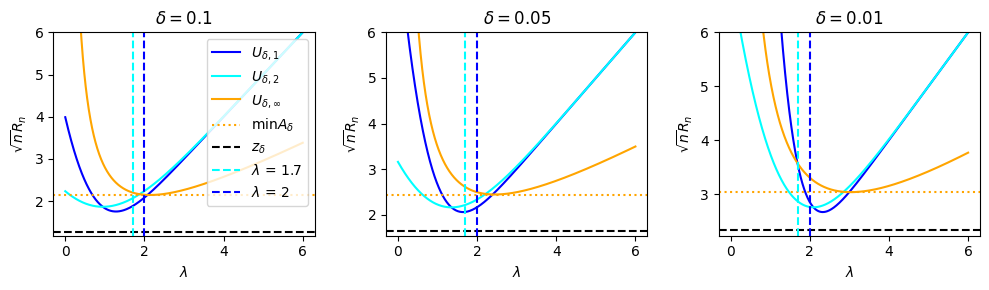

In [15]:
deltas = [0.1, 0.05, 0.01]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='cyan')
    
    # y = f3(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    # y = f4(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    # y = f5(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 5}}$", color='brown')
    
    y_A = A(x, delta)
    ax.plot(x, y_A, label=fr"$U_{{\delta, \infty}}$", color='orange')

    # --- NEW: Plot horizontal line at the minimum of A_delta on the grid ---
    # We slice with x > 0 to avoid the division by zero at x=0
    min_A = np.nanmin(y_A[x > 0])
    ax.axhline(min_A, label=r"$\min A_{\delta}$", color='orange', linestyle=':')
    # -----------------------------------------------------------------------
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    vline = 1.7
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='cyan', linestyle='--')

    vline = 2
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='blue', linestyle='--')


    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot_posthoc_2.png", dpi=300)
plt.show()

# Multiple testing

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_3335/359341294.py:91: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2) / x


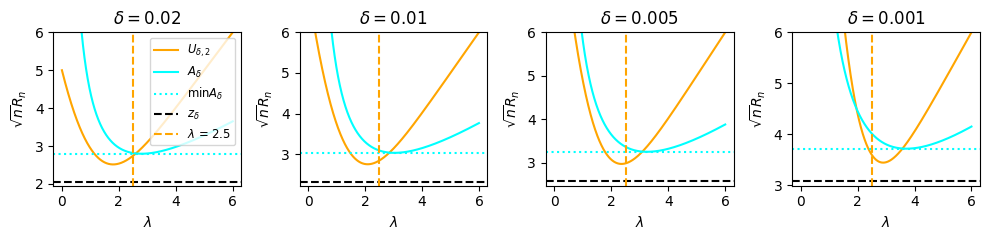

In [66]:
# deltas = [0.05, 0.02, 0.01, 0.005, 0.003, 0.001]
# fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# deltas = [0.1, 0.05, 0.01]
# fig, axes = plt.subplots(1, 3, figsize=(10, 6))

deltas = [0.02, 0.01, 0.005, 0.001]
fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    # y = f1(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    # y = f3(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    # y = f4(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    
    y_A = A(x, delta)
    ax.plot(x, y_A, label=fr"$A_{{\delta}}$", color='cyan')

    # --- NEW: Plot horizontal line at the minimum of A_delta on the grid ---
    # We slice with x > 0 to avoid the division by zero at x=0
    min_A = np.nanmin(y_A[x > 0])
    ax.axhline(min_A, label=r"$\min A_{\delta}$", color='cyan', linestyle=':')
    # -----------------------------------------------------------------------
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    vline = 2.5
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='orange', linestyle='--')


    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right', fontsize="small")

plt.tight_layout()
plt.savefig(f"plots/bounds_plot_multiple_testing.png", dpi=300)
plt.show()

/tmp/ipykernel_461351/359341294.py:91: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2) / x


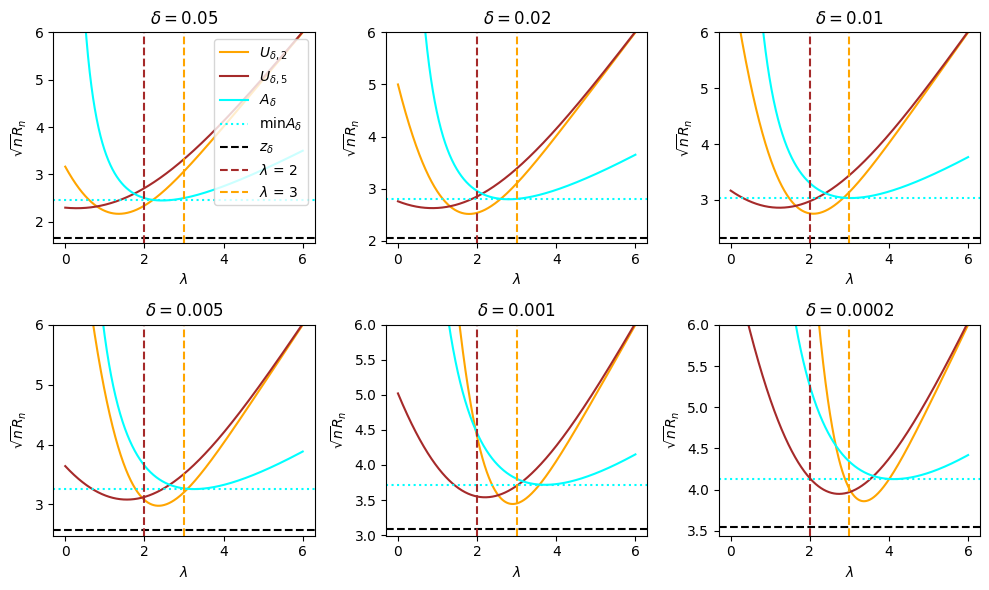

In [6]:
deltas = [0.05, 0.02, 0.01, 0.005, 0.001, 0.0002]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# deltas = [0.1, 0.05, 0.01]
# fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    # y = f1(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    # y = f3(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    # y = f4(x, delta)
    # ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    y = f5(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 5}}$", color='brown')

    
    y_A = A(x, delta)
    ax.plot(x, y_A, label=fr"$A_{{\delta}}$", color='cyan')

    # --- NEW: Plot horizontal line at the minimum of A_delta on the grid ---
    # We slice with x > 0 to avoid the division by zero at x=0
    min_A = np.nanmin(y_A[x > 0])
    ax.axhline(min_A, label=r"$\min A_{\delta}$", color='cyan', linestyle=':')
    # -----------------------------------------------------------------------
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    vline = 2
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='brown', linestyle='--')

    vline = 3
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='orange', linestyle='--')


    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot_multiple_testing1.png", dpi=300)
plt.show()